# Анализ личных финансов: июнь — сентябрь 2026

**Цель.** По выписке из банка понять, куда уходят деньги, проверить несколько гипотез
о моих тратах и составить бюджет на октябрь, который укладывается в доход.

**Данные.** Выписка Т-Банка за 01.06–30.09.2026, 1 115 операций. PDF распарсен скриптом
`src/parse_statement.py` (итоги сверены с выпиской до копейки), категории проставлены правилами
в `src/categorize.py`, персональные данные удалены.

**Структура:**
1. Загрузка и подготовка данных
2. Денежный поток: доходы vs расходы
3. Структура и динамика трат
4. Проверка гипотез
5. Бюджет на октябрь
6. Выводы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format",
              lambda x: f"{x:,.0f}".replace(",", " ") if abs(x) >= 10 or x == round(x) else f"{x:.1f}")

def rub_fmt(x):
    # 12345.6 -> '12 346 ₽'

    return f"{x:,.0f}".replace(",", " ") + " ₽"
plt.rcParams.update({
    "figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})
rub = mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k".replace(",", " "))
MONTHS = {6: "Июнь", 7: "Июль", 8: "Август", 9: "Сентябрь"}

## 1. Загрузка и подготовка данных

In [2]:
df = pd.read_csv("../data/transactions.csv", parse_dates=["date"])
df["hour"] = df["time"].str[:2].astype(int)
df["month"] = df["date"].dt.month

# 1 октября — неполный месяц, в помесячном анализе не участвует
df = df[df["date"] < "2026-10-01"].copy()
print(f"Операций: {len(df)},  период: {df.date.min():%d.%m.%Y} — {df.date.max():%d.%m.%Y}")
df.head()

Операций: 1110,  период: 01.06.2026 — 30.09.2026


,date,time,amount,type,category,merchant,hour,month
0,2026-06-01,15:30,-184,expense,Продукты,Продуктовый магазин,15,6
1,2026-06-01,16:22,-80,expense,Продукты,Универсам,16,6
2,2026-06-01,16:23,-324,expense,Мелкие точки (ИП),ИП (название скрыто),16,6
3,2026-06-01,16:54,52,internal,Переводы между своими счетами,Свой счёт,16,6
4,2026-06-01,17:01,52,internal,Переводы между своими счетами,Свой счёт,17,6


Каждая операция отнесена к одному из типов:

| type | что это | участвует в анализе |
|---|---|---|
| `expense` | покупки, переводы людям, снятие наличных | расходы |
| `refund` | возвраты за покупки | уменьшают расходы своей категории |
| `income` | зарплата | доход |
| `other_income` | переводы от других людей, кэшбэк | показаны отдельно |
| `internal` | переводы между своими счетами | **исключены** — это не траты |

Последний пункт важен: по итогам выписки «расходы» — 1,18 млн ₽, но больше половины этой суммы —
перекладывание денег между своими счетами. Без их исключения анализ был бы бессмысленным.

In [3]:
df.groupby("type")["amount"].agg(["count", "sum"]).rename(columns={"count": "операций", "sum": "сумма, ₽"})

,операций,"сумма, ₽"
type,,
expense,775,-683 662
income,4,265 000
internal,225,232 142
other_income,93,173 265
refund,13,10 036


In [4]:
# Расходы «нетто»: покупки минус возвраты; кэшбэк к расходам не относим
spend = df[df["type"].isin(["expense", "refund"]) & (df["category"] != "Кэшбэк и бонусы")].copy()
spend["value"] = -spend["amount"]

ONE_OFF = "Крупные разовые траты"
regular = spend[spend["category"] != ONE_OFF]

print("Разовые крупные траты:")
spend[spend["category"] == ONE_OFF][["date", "merchant", "value"]]

Разовые крупные траты:


,date,merchant,value
936,2026-09-05,Отдых в Турции,164 947
1100,2026-09-29,Покупка MacBook,95 000


## 2. Денежный поток: доходы vs расходы

In [5]:
flow = pd.DataFrame({
    "Зарплата": df[df.type == "income"].groupby("month")["amount"].sum(),
    "Поступления от людей и кэшбэк": df[df.type == "other_income"].groupby("month")["amount"].sum()
        + df[(df.type == "refund") & (df.category == "Кэшбэк и бонусы")].groupby("month")["amount"].sum(),
    "Регулярные расходы": regular.groupby("month")["value"].sum(),
    "Разовые траты": spend[spend.category == ONE_OFF].groupby("month")["value"].sum(),
    "Пришло со своих счетов (накоплений)": df[df.type == "internal"].groupby("month")["amount"].sum(),
}).fillna(0).rename(index=MONTHS)
flow["Регулярные расходы − зарплата"] = flow["Регулярные расходы"] - flow["Зарплата"]
flow

,Зарплата,Поступления от людей и кэшбэк,Регулярные расходы,Разовые траты,Пришло со своих счетов (накоплений),Регулярные расходы − зарплата
month,,,,,,
Июнь,0,38 744,123 017,0,80 373,123 017
Июль,75 000,44 105,90 180,0,-30 220,15 180
Август,60 000,41 170,91 129,0,-8 804,31 129
Сентябрь,130 000,53 523,113 628,259 947,190 794,-16 372


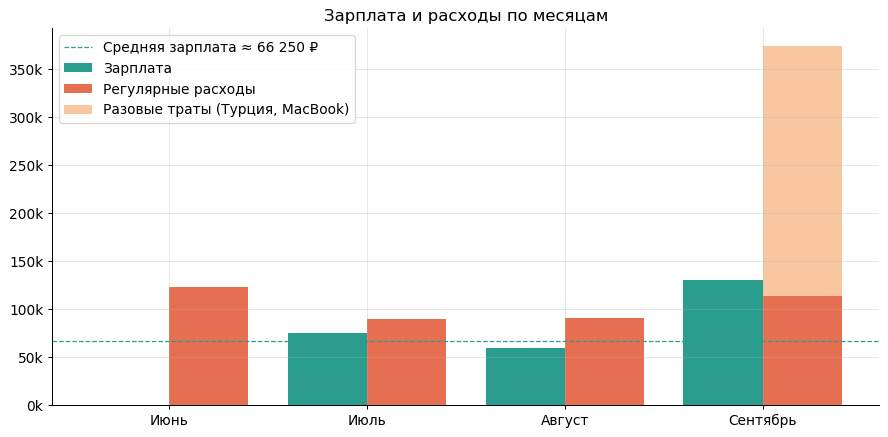

In [6]:
fig, ax = plt.subplots()
x = np.arange(len(flow))
ax.bar(x - 0.2, flow["Зарплата"], 0.4, label="Зарплата", color="#2a9d8f")
ax.bar(x + 0.2, flow["Регулярные расходы"], 0.4, label="Регулярные расходы", color="#e76f51")
ax.bar(x + 0.2, flow["Разовые траты"], 0.4, bottom=flow["Регулярные расходы"],
       label="Разовые траты (Турция, MacBook)", color="#f4a261", alpha=0.6)
ax.axhline(flow["Зарплата"].mean(), ls="--", color="#2a9d8f", lw=1,
           label=f"Средняя зарплата ≈ {flow['Зарплата'].mean():,.0f} ₽".replace(",", " "))
ax.set_xticks(x, flow.index); ax.yaxis.set_major_formatter(rub)
ax.set_title("Зарплата и расходы по месяцам"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("../images/01_cashflow.png", dpi=120); plt.show()

In [7]:
total_salary = flow["Зарплата"].sum()
total_regular = flow["Регулярные расходы"].sum()
print(f"Зарплата за 4 месяца:            {rub_fmt(total_salary):>12}")
print(f"Регулярные расходы за 4 месяца:  {rub_fmt(total_regular):>12}")
print(f"Регулярные расходы / зарплата:   {total_regular / total_salary:>12.0%}")
print(f"Чистый приток со своих счетов:   {rub_fmt(flow['Пришло со своих счетов (накоплений)'].sum()):>12}")

Зарплата за 4 месяца:               265 000 ₽
Регулярные расходы за 4 месяца:     417 954 ₽
Регулярные расходы / зарплата:           158%
Чистый приток со своих счетов:      232 142 ₽


**Что видно:** даже без поездки и ноутбука регулярные расходы стабильно выше зарплаты.
Разница покрывалась переводами от других людей и деньгами с собственных счетов
(со своих счетов за 4 месяца пришло ~230 тыс. ₽). Это главный вывод, от которого строится
бюджет в разделе 5.

## 3. Структура и динамика трат

In [8]:
by_cat = regular.pivot_table(index="category", columns="month", values="value",
                             aggfunc="sum", fill_value=0).rename(columns=MONTHS)
by_cat["Среднее"] = by_cat.mean(axis=1)
by_cat["Доля, %"] = (by_cat["Среднее"] / by_cat["Среднее"].sum() * 100).round(1)
by_cat = by_cat.sort_values("Среднее", ascending=False)
by_cat

month,Июнь,Июль,Август,Сентябрь,Среднее,"Доля, %"
category,,,,,,
Переводы людям,15 024,22 747,21 983,30 886,22 660,22
Продукты,28 773,16 582,11 818,11 929,17 275,16
Кафе и рестораны,23 484,10 988,7 011,21 734,15 804,15
Покупки,24 378,13 507,7 014,15 235,15 033,14
Такси,1 326,8 779,4 154,12 286,6 636,6.4
Развлечения,3 075,2 386,18 700,499,6 165,5.9
Алкоголь и табак,7 261,1 746,1 249,2 097,3 088,3
Общественный транспорт,1 615,3 266,4 481,2 936,3 074,2.9
Учёба,5 392,0,0,5 752,2 786,2.7


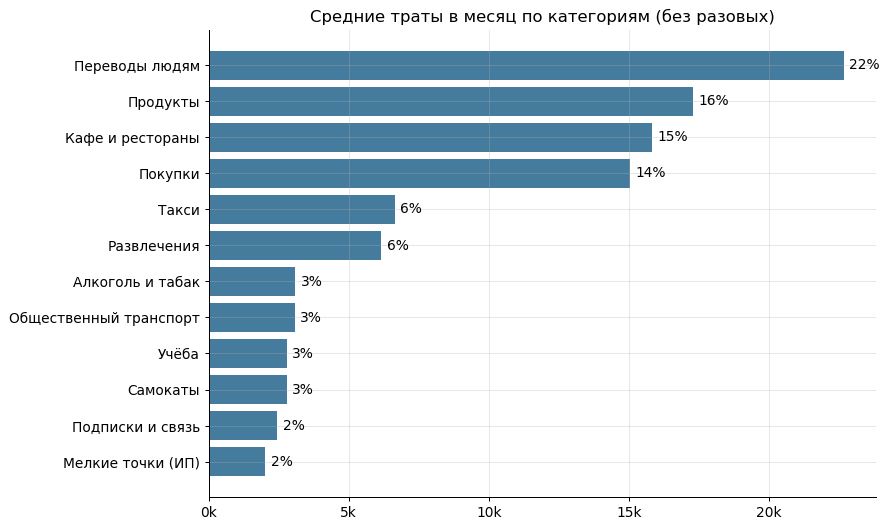

In [9]:
top = by_cat["Среднее"].head(12)[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top.index, top.values, color="#457b9d")
for b, share in zip(bars, by_cat["Доля, %"].head(12)[::-1]):
    ax.text(b.get_width() + 200, b.get_y() + b.get_height() / 2, f"{share:.0f}%", va="center")
ax.xaxis.set_major_formatter(rub)
ax.set_title("Средние траты в месяц по категориям (без разовых)")
plt.tight_layout(); plt.savefig("../images/02_categories.png", dpi=120); plt.show()

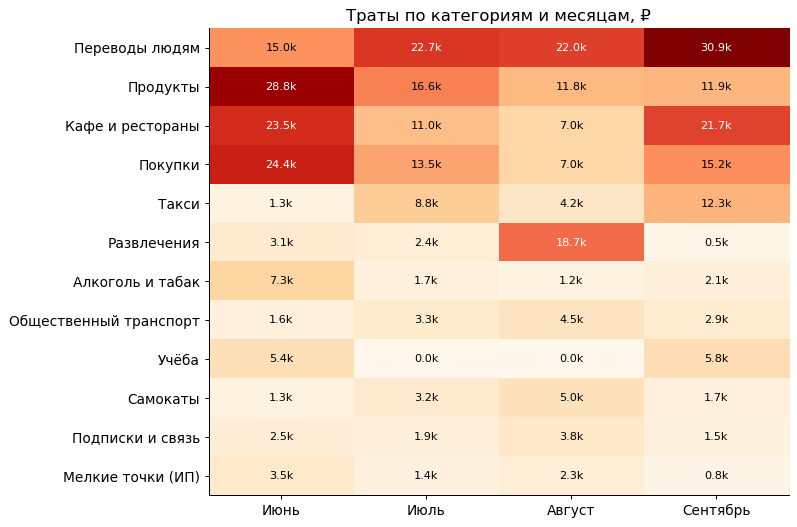

In [10]:
heat = by_cat[list(MONTHS.values())].head(12)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heat.values, cmap="OrRd", aspect="auto")
ax.set_xticks(range(heat.shape[1]), heat.columns); ax.set_yticks(range(heat.shape[0]), heat.index)
ax.grid(False)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v/1000:.1f}k", ha="center", va="center",
                color="white" if v > heat.values.max() * 0.6 else "black", fontsize=9)
ax.set_title("Траты по категориям и месяцам, ₽")
plt.tight_layout(); plt.savefig("../images/03_heatmap.png", dpi=120); plt.show()

In [11]:
# Изменение сентябрь vs июль — что выросло сильнее всего
delta = (by_cat["Сентябрь"] - by_cat["Июль"]).sort_values()
print("Сентябрь vs июль, ₽:")
delta[delta.abs() > 1000]

Сентябрь vs июль, ₽:


,0
category,
Продукты,-4 653
Развлечения,-1 887
Здоровье,-1 806
Самокаты,-1 453
Комиссии,1 035
Покупки,1 728
Такси,3 507
Путешествия,4 096
Учёба,5 752


## 4. Проверка гипотез

Для каждой гипотезы: формулировка → проверка на данных → вывод.

### Гипотеза 1. Такси дорожает, и в основном это ночные поездки

In [12]:
taxi = regular[regular.category == "Такси"].copy()
taxi["Время"] = np.where(taxi["hour"] < 6, "Ночь (00–06)", "День")
t = taxi.pivot_table(index="month", columns="Время", values="value", aggfunc="sum",
                     fill_value=0).rename(index=MONTHS)
t["Всего"] = t.sum(axis=1)
print(f"Поездок: {len(taxi)}, средний чек: {rub_fmt(taxi.value.mean())}, "
      f"доля ночных поездок в сумме: {taxi[taxi.hour < 6].value.sum() / taxi.value.sum():.0%}")
t

Поездок: 33, средний чек: 804 ₽, доля ночных поездок в сумме: 58%


Время,День,Ночь (00–06),Всего
month,,,
Июнь,1 326,0,1 326
Июль,3 043,5 736,8 779
Август,1 625,2 529,4 154
Сентябрь,5 168,7 118,12 286


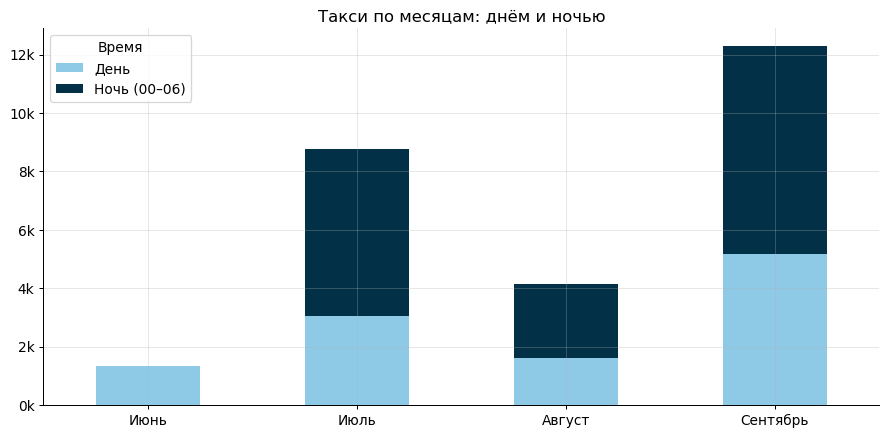

In [13]:
ax = t[["День", "Ночь (00–06)"]].plot(kind="bar", stacked=True, color=["#8ecae6", "#023047"], rot=0)
ax.yaxis.set_major_formatter(rub); ax.set_xlabel("")
ax.set_title("Такси по месяцам: днём и ночью")
plt.tight_layout(); plt.savefig("../images/04_taxi.png", dpi=120); plt.show()

**Вывод: гипотеза подтверждается.** В июне такси почти не было, к сентябрю траты выросли примерно в 9 раз.
Больше половины суммы — поездки после полуночи, т.е. дорога домой после баров и встреч.
Это самая «управляемая» статья: планировать возвращение до закрытия метро или делить поездку
с друзьями.

### Гипотеза 2. Существенная часть трат приходится на ночь и выходные

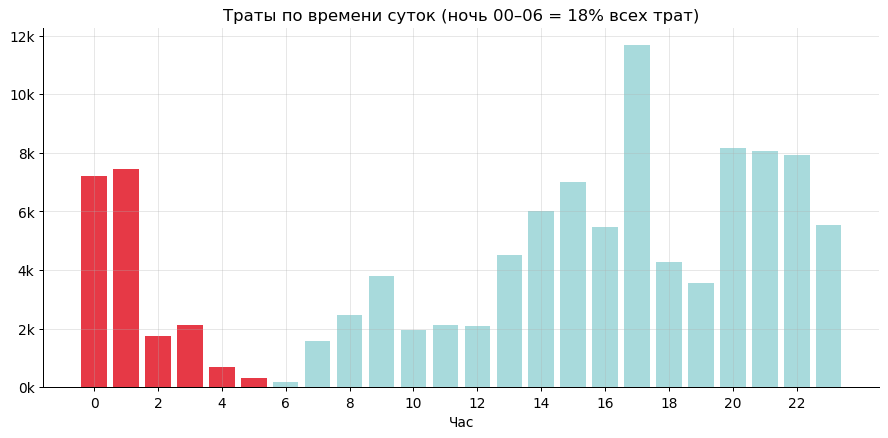

,value
category,
Кафе и рестораны,6 068
Переводы людям,3 854
Такси,3 846
Покупки,3 520
Продукты,1 031


In [14]:
hourly = regular[regular.type == "expense"].groupby("hour")["value"].sum() / 4  # в среднем за месяц
night_share = hourly.loc[0:5].sum() / hourly.sum()

fig, ax = plt.subplots()
ax.bar(hourly.index, hourly.values,
       color=["#e63946" if h < 6 else "#a8dadc" for h in hourly.index])
ax.yaxis.set_major_formatter(rub); ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Час"); ax.set_title(f"Траты по времени суток (ночь 00–06 = {night_share:.0%} всех трат)")
plt.tight_layout(); plt.savefig("../images/05_hours.png", dpi=120); plt.show()

night = regular[(regular.type == "expense") & (regular.hour < 6)]
night.groupby("category")["value"].sum().sort_values(ascending=False).head(5) / 4

In [15]:
days = pd.DataFrame({"date": pd.date_range("2026-06-01", "2026-09-30")})
daily = regular.groupby("date")["value"].sum()
days["value"] = days["date"].map(daily).fillna(0)
days["Выходной"] = days["date"].dt.dayofweek >= 5
wk = days.groupby("Выходной")["value"].mean().rename({False: "Будний день", True: "Выходной"})
print(f"Выходной день дороже буднего на {wk['Выходной'] / wk['Будний день'] - 1:.0%}")
wk

Выходной день дороже буднего на 29%


,value
Выходной,
Будний день,3 171
Выходной,4 084


**Вывод: подтверждается.** Почти пятая часть всех трат совершается ночью — это кафе и бары,
такси и спонтанные покупки. Выходной день в среднем дороже буднего.

### Гипотеза 3. Еда вне дома обходится почти как продукты

In [16]:
food = by_cat.loc[["Продукты", "Кафе и рестораны"], list(MONTHS.values())].T
food["Кафе / продукты"] = (food["Кафе и рестораны"] / food["Продукты"]).round(2)
food

category,Продукты,Кафе и рестораны,Кафе / продукты
month,,,
Июнь,28 773,23 484,0.8
Июль,16 582,10 988,0.7
Август,11 818,7 011,0.6
Сентябрь,11 929,21 734,1.8


**Вывод: подтверждается частично.** В среднем кафе и рестораны — около 90% от суммы на продукты,
а в сентябре траты в кафе почти в 2 раза превысили продукты. Каждый поход в кафе заменяет
несколько приёмов пищи из магазина, поэтому сокращение здесь даёт заметную экономию.

### Гипотеза 4. Много мелких трат незаметно складываются в крупную сумму

In [17]:
small = regular[(regular.type == "expense") & (regular.value < 300)]
print(f"Операций дешевле 300 ₽: {len(small)} из {len(regular)} ({len(small)/len(regular):.0%})")
print(f"Их сумма в месяц: {rub_fmt(small.value.sum() / 4)}")
scoot = regular[regular.category == "Самокаты"]
print(f"Самокаты: {len(scoot)} поездок, медианная поездка {rub_fmt(scoot.value.median())}, "
      f"в месяц {rub_fmt(scoot.value.sum() / 4)}")
small.groupby("category")["value"].agg(["count", "sum"]).sort_values("sum", ascending=False).head(6)

Операций дешевле 300 ₽: 490 из 777 (63%)
Их сумма в месяц: 13 623 ₽
Самокаты: 192 поездок, медианная поездка 38 ₽, в месяц 2 784 ₽


,count,sum
category,,
Продукты,105,17 041
Самокаты,191,10 638
Общественный транспорт,75,6 578
Мелкие точки (ИП),25,4 884
Кафе и рестораны,26,4 322
Алкоголь и табак,16,2 667


**Вывод: подтверждается.** Больше половины операций — мелкие (до 300 ₽), и вместе они дают
ощутимую сумму в месяц. Самый яркий пример — 192 поездки на самокатах по ~40 ₽.

### Гипотеза 5. Есть дублирующиеся подписки

In [18]:
subs = regular[regular.category == "Подписки и связь"]
subs.groupby("merchant")["value"].agg(["count", "sum"]).sort_values("sum", ascending=False)

,count,sum
merchant,,
Т-Банк подписки,8,4 283
Мобильная связь,9,1 536
Telegram Premium,1,1 399
Домашний интернет,1,900
planetconfig,1,499
Яндекс Плюс,1,399
Яндекс (подписка),2,298
VPN (Telegram-бот),1,249
VK Музыка,1,199


**Вывод: подтверждается.** Одновременно оплачиваются подписки Т-Банка (Premium и Pro), Яндекс Плюс,
VK Музыка и Telegram Premium. Часть функций пересекается (музыка, кэшбэк), одну-две можно отключить.

## 5. Бюджет на октябрь

**Логика расчёта:**
1. **Доход** — средняя зарплата за 4 месяца.
2. **Цель** — уложиться в доход и откладывать 10%.
3. **База** по каждой категории — медиана за 4 месяца.
4. **Обязательные** категории (продукты, транспорт, учёба, связь, здоровье) оставляю на уровне базы.
5. **Гибкие** категории сокращаю на одинаковый процент, но не больше установленного предела для каждой.

In [19]:
INCOME = flow["Зарплата"].mean()
SAVINGS_RATE = 0.10
LIMIT = INCOME * (1 - SAVINGS_RATE)

# максимальное разумное сокращение для гибких категорий
FLEXIBLE_MAX_CUT = {
    "Кафе и рестораны": 0.6, "Такси": 0.7, "Покупки": 0.7, "Развлечения": 0.6,
    "Алкоголь и табак": 0.7, "Самокаты": 0.5, "Переводы людям": 0.4,
    "Мелкие точки (ИП)": 0.5, "Прочие сервисы": 0.5, "Наличные": 0.5,
    "Подписки и связь": 0.4, "Путешествия": 1.0, "Комиссии": 1.0,
}

base = regular.pivot_table(index="category", columns="month", values="value",
                           aggfunc="sum", fill_value=0).median(axis=1)
flexible = base[base.index.isin(FLEXIBLE_MAX_CUT)]
essential = base[~base.index.isin(FLEXIBLE_MAX_CUT)]

need_to_cut = base.sum() - LIMIT
print(f"Доход (средняя зарплата):  {rub_fmt(INCOME):>10}")
print(f"Лимит трат (−{SAVINGS_RATE:.0%} в копилку): {rub_fmt(LIMIT):>10}")
print(f"Базовые траты (медиана):   {rub_fmt(base.sum()):>10}")
print(f"Нужно сократить:           {rub_fmt(need_to_cut):>10}")

Доход (средняя зарплата):    66 250 ₽
Лимит трат (−10% в копилку):   59 625 ₽
Базовые траты (медиана):     93 676 ₽
Нужно сократить:             34 051 ₽


In [20]:
# Подбираем единый процент сокращения гибких категорий (с учётом пределов) бинарным поиском
def cut_amount(rate):
    return sum(v * min(rate, FLEXIBLE_MAX_CUT[c]) for c, v in flexible.items())

lo, hi = 0.0, 1.0
for _ in range(50):
    mid = (lo + hi) / 2
    lo, hi = (mid, hi) if cut_amount(mid) < need_to_cut else (lo, mid)
rate = hi

plan = pd.DataFrame({"База (медиана)": base})
plan["Тип"] = np.where(plan.index.isin(FLEXIBLE_MAX_CUT), "гибкая", "обязательная")
cut = pd.Series([min(rate, FLEXIBLE_MAX_CUT.get(c, 0)) for c in plan.index], index=plan.index)
plan["Сокращение, %"] = (cut * 100).round(0)
plan["Лимит на октябрь"] = (plan["База (медиана)"] * (1 - cut)).round(-2)
plan["Экономия"] = (plan["База (медиана)"] - plan["Лимит на октябрь"]).round(0)
plan = plan.sort_values("Экономия", ascending=False)

gap = plan["Лимит на октябрь"].sum() - LIMIT
print(f"Единый процент сокращения гибких категорий: {rate:.0%}")
print(f"Итого лимит: {rub_fmt(plan['Лимит на октябрь'].sum())} "
      f"({'в рамках цели' if gap <= 100 else 'не хватает ещё ' + rub_fmt(gap)})")
plan

Единый процент сокращения гибких категорий: 50%
Итого лимит: 59 600 ₽ (в рамках цели)


,База (медиана),Тип,"Сокращение, %",Лимит на октябрь,Экономия
category,,,,,
Переводы людям,22 365,гибкая,40,13 400,8 965
Кафе и рестораны,16 361,гибкая,50,8 100,8 261
Покупки,14 371,гибкая,50,7 100,7 271
Такси,6 466,гибкая,50,3 200,3 266
Развлечения,2 730,гибкая,50,1 400,1 330
Самокаты,2 428,гибкая,50,1 200,1 228
Мелкие точки (ИП),1 870,гибкая,50,900,970
Алкоголь и табак,1 922,гибкая,50,1 000,922
Подписки и связь,2 183,гибкая,40,1 300,883


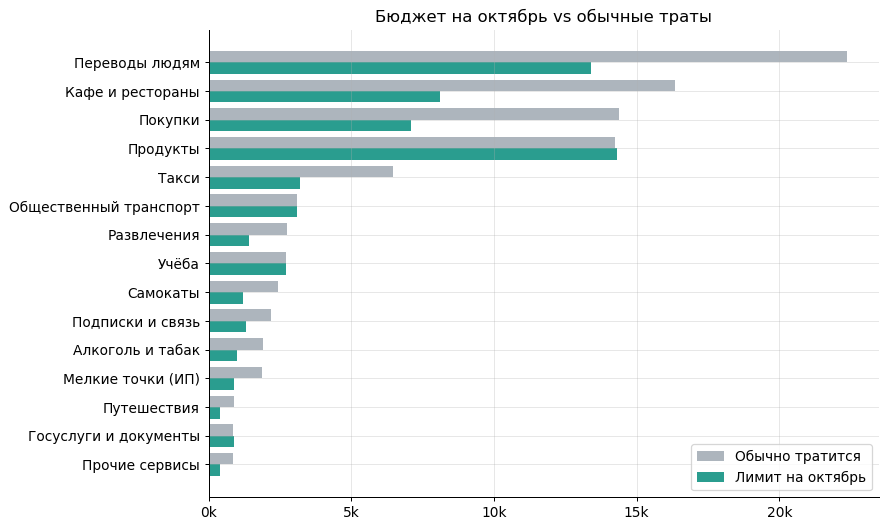

In [21]:
p = plan[plan["База (медиана)"] > 500].sort_values("База (медиана)")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(p))
ax.barh(y + 0.2, p["База (медиана)"], 0.4, label="Обычно тратится", color="#adb5bd")
ax.barh(y - 0.2, p["Лимит на октябрь"], 0.4, label="Лимит на октябрь", color="#2a9d8f")
ax.set_yticks(y, p.index); ax.xaxis.set_major_formatter(rub); ax.legend()
ax.set_title("Бюджет на октябрь vs обычные траты")
plt.tight_layout(); plt.savefig("../images/06_october_plan.png", dpi=120); plt.show()

In [22]:
# Конкретные рекомендации — генерируются из таблицы плана
print("Что сократить в октябре, чтобы не выйти за доход:\n")
for cat, row in plan[plan["Экономия"] >= 500].iterrows():
    print(f"• {cat}: не больше {rub_fmt(row['Лимит на октябрь'])} "
          f"(обычно {rub_fmt(row['База (медиана)'])}, экономия {rub_fmt(row['Экономия'])})")
print(f"\nОбщая экономия: {rub_fmt(plan['Экономия'].sum())} в месяц")

Что сократить в октябре, чтобы не выйти за доход:

• Переводы людям: не больше 13 400 ₽ (обычно 22 365 ₽, экономия 8 965 ₽)
• Кафе и рестораны: не больше 8 100 ₽ (обычно 16 361 ₽, экономия 8 261 ₽)
• Покупки: не больше 7 100 ₽ (обычно 14 371 ₽, экономия 7 271 ₽)
• Такси: не больше 3 200 ₽ (обычно 6 466 ₽, экономия 3 266 ₽)
• Развлечения: не больше 1 400 ₽ (обычно 2 730 ₽, экономия 1 330 ₽)
• Самокаты: не больше 1 200 ₽ (обычно 2 428 ₽, экономия 1 228 ₽)
• Мелкие точки (ИП): не больше 900 ₽ (обычно 1 870 ₽, экономия 970 ₽)
• Алкоголь и табак: не больше 1 000 ₽ (обычно 1 922 ₽, экономия 922 ₽)
• Подписки и связь: не больше 1 300 ₽ (обычно 2 183 ₽, экономия 883 ₽)
• Путешествия: не больше 400 ₽ (обычно 907 ₽, экономия 507 ₽)

Общая экономия: 34 075 ₽ в месяц


## 6. Выводы

1. **Траты превышают доход.** Регулярные расходы
   в 1,6 раза больше зарплаты. Разница покрывалась переводами от других людей и накоплениями —
   так долго продолжаться не может.
2. **Основные «утечки»:** переводы людям, кафе и бары, покупки и такси.
   Вместе это почти 60% регулярных трат. Часть переводов людям - типичная трата,
   которую потом возвращают (поступления от людей ~43 тыс. ₽ в месяц), поэтому реальная нагрузка
   этой категории ниже.
3. **Поведенческие паттерны:** почти 20% трат — ночью (бары, такси домой), выходные дороже будних,
   больше половины операций — мелкие покупки до 300 ₽.
4. **План на октябрь:** обязательные траты оставить как есть, гибкие сократить по таблице выше.
   Это позволяет уложиться в зарплату и отложить 10%.

**Ограничения анализа.** Зарплата вносилась наличными и была сезонной — если доход
изменится, достаточно поменять `INCOME` и пересчитать раздел 5.

**Что можно улучшить:** собрать данные за год для учёта сезонности, добавить вторую карту,
сделать дашборд (Streamlit / DataLens) с ежемесячным обновлением.